In [9]:
# === DIAGNOSTIC: Which H3 trades win, which lose? ===

if len(trades_h3_df) > 0:
    # 1. Performance by hour
    print("=== H3 Performance by Hour ===")
    by_hour = trades_h3_df.groupby('hour').agg(
        trades=('net_pl_usd', 'count'),
        win_rate=('net_pl_usd', lambda x: (x > 0).mean() * 100),
        total_pl=('net_pl_usd', 'sum'),
        avg_pl=('net_pl_usd', 'mean')
    )
    print(by_hour.to_string())
    
    # 2. Performance by direction
    print("\n=== H3 Performance by Direction ===")
    by_dir = trades_h3_df.groupby('direction').agg(
        trades=('net_pl_usd', 'count'),
        win_rate=('net_pl_usd', lambda x: (x > 0).mean() * 100),
        total_pl=('net_pl_usd', 'sum'),
        avg_pl=('net_pl_usd', 'mean')
    )
    print(by_dir.to_string())
    
    # 3. Performance by extension size (how far from VWAP)
    print("\n=== H3 Performance by Extension Size ===")
    trades_h3_df['ext_atr'] = trades_h3_df['dist_from_vwap'].abs() / trades_h3_df['atr']
    trades_h3_df['ext_bucket'] = pd.cut(
        trades_h3_df['ext_atr'], 
        bins=[1.5, 2.0, 2.5, 3.0, 4.0, 100],
        labels=['1.5-2.0 ATR', '2.0-2.5 ATR', '2.5-3.0 ATR', '3.0-4.0 ATR', '4.0+ ATR']
    )
    by_ext = trades_h3_df.groupby('ext_bucket', observed=True).agg(
        trades=('net_pl_usd', 'count'),
        win_rate=('net_pl_usd', lambda x: (x > 0).mean() * 100),
        avg_pl=('net_pl_usd', 'mean'),
        total_pl=('net_pl_usd', 'sum')
    )
    print(by_ext.to_string())
    
    # 4. Performance by ATR regime (volatility)
    print("\n=== H3 Performance by ATR Regime ===")
    trades_h3_df['atr_bucket'] = pd.cut(
        trades_h3_df['atr'],
        bins=[0, 0.6, 1.0, 1.5, 2.5, 100],
        labels=['Low (<0.6)', 'Med-Low (0.6-1.0)', 'Med (1.0-1.5)', 'High (1.5-2.5)', 'V.High (2.5+)']
    )
    by_atr = trades_h3_df.groupby('atr_bucket', observed=True).agg(
        trades=('net_pl_usd', 'count'),
        win_rate=('net_pl_usd', lambda x: (x > 0).mean() * 100),
        avg_pl=('net_pl_usd', 'mean'),
        total_pl=('net_pl_usd', 'sum')
    )
    print(by_atr.to_string())
    
    # 5. SL hit vs TP hit timing
    print("\n=== Exit timing analysis ===")
    trades_h3_df['hold_minutes'] = (
        pd.to_datetime(trades_h3_df['exit_time']) - 
        pd.to_datetime(trades_h3_df['entry_time'])
    ).dt.total_seconds() / 60
    
    timing = trades_h3_df.groupby('exit_reason')['hold_minutes'].agg(['count', 'mean', 'median'])
    print(timing.to_string())

=== H3 Performance by Hour ===
      trades   win_rate    total_pl    avg_pl
hour                                         
13       193  39.896373  -61.071973 -0.316435
14       297  34.680135  -18.888800 -0.063599
15       282  30.141844 -279.017693 -0.989424

=== H3 Performance by Direction ===
           trades   win_rate    total_pl    avg_pl
direction                                         
BUY           375  32.533333 -285.527823 -0.761408
SELL          397  36.020151  -73.450643 -0.185014

=== H3 Performance by Extension Size ===
             trades   win_rate    avg_pl    total_pl
ext_bucket                                          
1.5-2.0 ATR     162  41.975309 -0.618443 -100.187830
2.0-2.5 ATR     161  37.267081 -0.685890 -110.428314
2.5-3.0 ATR      95  26.315789 -1.388514 -131.908831
3.0-4.0 ATR     146  30.136986 -0.800561 -116.881894
4.0+ ATR        208  32.692308  0.482829  100.428403

=== H3 Performance by ATR Regime ===
                trades   win_rate    avg_pl    

In [10]:
# === DIAGNOSTIC: Which H3 trades win, which lose? ===

if len(trades_h3_df) > 0:
    # 1. Performance by hour
    print("=== H3 Performance by Hour ===")
    by_hour = trades_h3_df.groupby('hour').agg(
        trades=('net_pl_usd', 'count'),
        win_rate=('net_pl_usd', lambda x: (x > 0).mean() * 100),
        total_pl=('net_pl_usd', 'sum'),
        avg_pl=('net_pl_usd', 'mean')
    )
    print(by_hour.to_string())
    
    # 2. Performance by direction
    print("\n=== H3 Performance by Direction ===")
    by_dir = trades_h3_df.groupby('direction').agg(
        trades=('net_pl_usd', 'count'),
        win_rate=('net_pl_usd', lambda x: (x > 0).mean() * 100),
        total_pl=('net_pl_usd', 'sum'),
        avg_pl=('net_pl_usd', 'mean')
    )
    print(by_dir.to_string())
    
    # 3. Performance by extension size (how far from VWAP)
    print("\n=== H3 Performance by Extension Size ===")
    trades_h3_df['ext_atr'] = trades_h3_df['dist_from_vwap'].abs() / trades_h3_df['atr']
    trades_h3_df['ext_bucket'] = pd.cut(
        trades_h3_df['ext_atr'], 
        bins=[1.5, 2.0, 2.5, 3.0, 4.0, 100],
        labels=['1.5-2.0 ATR', '2.0-2.5 ATR', '2.5-3.0 ATR', '3.0-4.0 ATR', '4.0+ ATR']
    )
    by_ext = trades_h3_df.groupby('ext_bucket', observed=True).agg(
        trades=('net_pl_usd', 'count'),
        win_rate=('net_pl_usd', lambda x: (x > 0).mean() * 100),
        avg_pl=('net_pl_usd', 'mean'),
        total_pl=('net_pl_usd', 'sum')
    )
    print(by_ext.to_string())
    
    # 4. Performance by ATR regime (volatility)
    print("\n=== H3 Performance by ATR Regime ===")
    trades_h3_df['atr_bucket'] = pd.cut(
        trades_h3_df['atr'],
        bins=[0, 0.6, 1.0, 1.5, 2.5, 100],
        labels=['Low (<0.6)', 'Med-Low (0.6-1.0)', 'Med (1.0-1.5)', 'High (1.5-2.5)', 'V.High (2.5+)']
    )
    by_atr = trades_h3_df.groupby('atr_bucket', observed=True).agg(
        trades=('net_pl_usd', 'count'),
        win_rate=('net_pl_usd', lambda x: (x > 0).mean() * 100),
        avg_pl=('net_pl_usd', 'mean'),
        total_pl=('net_pl_usd', 'sum')
    )
    print(by_atr.to_string())
    
    # 5. SL hit vs TP hit timing
    print("\n=== Exit timing analysis ===")
    trades_h3_df['hold_minutes'] = (
        pd.to_datetime(trades_h3_df['exit_time']) - 
        pd.to_datetime(trades_h3_df['entry_time'])
    ).dt.total_seconds() / 60
    
    timing = trades_h3_df.groupby('exit_reason')['hold_minutes'].agg(['count', 'mean', 'median'])
    print(timing.to_string())

=== H3 Performance by Hour ===
      trades   win_rate    total_pl    avg_pl
hour                                         
13       193  39.896373  -61.071973 -0.316435
14       297  34.680135  -18.888800 -0.063599
15       282  30.141844 -279.017693 -0.989424

=== H3 Performance by Direction ===
           trades   win_rate    total_pl    avg_pl
direction                                         
BUY           375  32.533333 -285.527823 -0.761408
SELL          397  36.020151  -73.450643 -0.185014

=== H3 Performance by Extension Size ===
             trades   win_rate    avg_pl    total_pl
ext_bucket                                          
1.5-2.0 ATR     162  41.975309 -0.618443 -100.187830
2.0-2.5 ATR     161  37.267081 -0.685890 -110.428314
2.5-3.0 ATR      95  26.315789 -1.388514 -131.908831
3.0-4.0 ATR     146  30.136986 -0.800561 -116.881894
4.0+ ATR        208  32.692308  0.482829  100.428403

=== H3 Performance by ATR Regime ===
                trades   win_rate    avg_pl    

In [11]:
# === HYPOTHESIS 4: Filtered VWAP Reversion ===
# Combines insights from H3 diagnostics:
# - Only deep extensions (≥ 2.5 ATR from VWAP)
# - Drop hour 15 (was bleeding the strategy)
# - Test BUY and SELL separately to see direction asymmetry

ATR_MULT_FROM_VWAP = 2.5    # raised from 1.5 — only deep extensions
ATR_MULT_SL        = 1.0
MAX_SPREAD         = 0.35
TIMEOUT_MIN        = 25
TRADE_HOURS        = [13, 14]  # dropped hour 15
ENTRY_COST_USD     = 0.33
MIN_TP_ATR         = 1.0
TP_VWAP_FRACTION   = 0.7

trades_h4 = []
i = 50

while i < len(df) - TIMEOUT_MIN:
    row = df.iloc[i]
    
    if row['hour'] not in TRADE_HOURS:
        i += 1
        continue
    if row['spread_usd'] > MAX_SPREAD:
        i += 1
        continue
    if pd.isna(row['atr14']) or row['atr14'] < 0.4:
        i += 1
        continue
    if pd.isna(row['vwap']):
        i += 1
        continue
    
    atr = row['atr14']
    dist = row['dist_from_vwap']
    
    direction = None
    if dist > ATR_MULT_FROM_VWAP * atr and row['bearish_candle']:
        direction = 'SELL'
    elif dist < -ATR_MULT_FROM_VWAP * atr and row['bullish_candle']:
        direction = 'BUY'
    
    if direction is None:
        i += 1
        continue
    
    entry_price = row['Close']
    entry_time = df.index[i]
    target_distance = max(abs(dist) * TP_VWAP_FRACTION, MIN_TP_ATR * atr)
    
    if direction == 'BUY':
        sl = entry_price - ATR_MULT_SL * atr
        tp = entry_price + target_distance
    else:
        sl = entry_price + ATR_MULT_SL * atr
        tp = entry_price - target_distance
    
    exit_price, exit_reason, exit_time = None, None, None
    
    for j in range(i + 1, min(i + 1 + TIMEOUT_MIN, len(df))):
        bar = df.iloc[j]
        if direction == 'BUY':
            if bar['Low'] <= sl:
                exit_price, exit_reason, exit_time = sl, 'SL', df.index[j]
                break
            if bar['High'] >= tp:
                exit_price, exit_reason, exit_time = tp, 'TP', df.index[j]
                break
        else:
            if bar['High'] >= sl:
                exit_price, exit_reason, exit_time = sl, 'SL', df.index[j]
                break
            if bar['Low'] <= tp:
                exit_price, exit_reason, exit_time = tp, 'TP', df.index[j]
                break
    
    if exit_price is None:
        exit_idx = min(i + TIMEOUT_MIN, len(df) - 1)
        exit_price = df.iloc[exit_idx]['Close']
        exit_reason = 'TIMEOUT'
        exit_time = df.index[exit_idx]
    
    if direction == 'BUY':
        gross_pl = exit_price - entry_price
    else:
        gross_pl = entry_price - exit_price
    
    net_pl = gross_pl - (ENTRY_COST_USD * 2)
    
    trades_h4.append({
        'entry_time': entry_time,
        'direction': direction,
        'entry': entry_price,
        'sl': sl,
        'tp': tp,
        'exit_time': exit_time,
        'exit': exit_price,
        'exit_reason': exit_reason,
        'atr': atr,
        'dist_from_vwap': dist,
        'gross_pl_usd': gross_pl,
        'net_pl_usd': net_pl,
        'hour': row['hour']
    })
    
    i = j + 1 if exit_price is not None else i + 1

trades_h4_df = pd.DataFrame(trades_h4)

print(f"=== HYPOTHESIS 4 (FILTERED VWAP REVERSION) RESULTS ===\n")
print(f"Total trades: {len(trades_h4_df)}")

if len(trades_h4_df) > 0:
    wins = trades_h4_df[trades_h4_df['net_pl_usd'] > 0]
    losses = trades_h4_df[trades_h4_df['net_pl_usd'] <= 0]
    
    win_rate = len(wins) / len(trades_h4_df) * 100
    gross_profit = wins['net_pl_usd'].sum()
    gross_loss = abs(losses['net_pl_usd'].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else float('inf')
    avg_win = wins['net_pl_usd'].mean() if len(wins) > 0 else 0
    avg_loss = losses['net_pl_usd'].mean() if len(losses) > 0 else 0
    total_pl = trades_h4_df['net_pl_usd'].sum()
    
    print(f"Win rate:      {win_rate:.1f}%")
    print(f"Wins:          {len(wins)}")
    print(f"Losses:        {len(losses)}")
    print(f"Avg win:       ${avg_win:.2f}/ounce")
    print(f"Avg loss:      ${avg_loss:.2f}/ounce")
    print(f"Profit factor: {profit_factor:.2f}")
    print(f"Total P/L:     ${total_pl:.2f}/ounce over all trades")
    
    print(f"\n=== Per Direction ===")
    by_dir = trades_h4_df.groupby('direction').agg(
        trades=('net_pl_usd', 'count'),
        win_rate=('net_pl_usd', lambda x: (x > 0).mean() * 100),
        avg_pl=('net_pl_usd', 'mean'),
        total_pl=('net_pl_usd', 'sum')
    )
    print(by_dir.to_string())
    
    print(f"\n=== Per Hour ===")
    by_hour = trades_h4_df.groupby('hour').agg(
        trades=('net_pl_usd', 'count'),
        win_rate=('net_pl_usd', lambda x: (x > 0).mean() * 100),
        avg_pl=('net_pl_usd', 'mean'),
        total_pl=('net_pl_usd', 'sum')
    )
    print(by_hour.to_string())
    
    days_traded = trades_h4_df['entry_time'].dt.date.nunique()
    print(f"\nTrading days: {days_traded}")
    print(f"Trades per active day: {len(trades_h4_df)/days_traded:.1f}")

print("\n\n=== ALL HYPOTHESES ===")
print(f"{'':<10} {'Trades':<10} {'PF':<8} {'Win%':<8} {'P/L':<10} {'PerTrade':<10}")
print("-" * 60)
for name, t_df in [('H1 Mom', trades_df), ('H2 Fade', trades_h2_df), 
                    ('H3 VWAP', trades_h3_df), ('H4 Filter', trades_h4_df)]:
    if len(t_df) > 0:
        w = t_df[t_df['net_pl_usd']>0]['net_pl_usd'].sum()
        l = abs(t_df[t_df['net_pl_usd']<=0]['net_pl_usd'].sum())
        pf = w/l if l > 0 else 0
        wr = (t_df['net_pl_usd']>0).mean()*100
        pl = t_df['net_pl_usd'].sum()
        per = t_df['net_pl_usd'].mean()
        print(f"{name:<10} {len(t_df):<10} {pf:<8.2f} {wr:<8.1f} {pl:<10.2f} {per:<10.2f}")

=== HYPOTHESIS 4 (FILTERED VWAP REVERSION) RESULTS ===

Total trades: 263
Win rate:      33.5%
Wins:          88
Losses:        175
Avg win:       $12.11/ounce
Avg loss:      $-5.75/ounce
Profit factor: 1.06
Total P/L:     $59.08/ounce over all trades

=== Per Direction ===
           trades   win_rate    avg_pl    total_pl
direction                                         
BUY           111  27.027027 -0.592526  -65.770335
SELL          152  38.157895  0.821373  124.848736

=== Per Hour ===
      trades   win_rate    avg_pl   total_pl
hour                                        
13        82  35.365854 -0.301983 -24.762596
14       181  32.596685  0.463210  83.840997

Trading days: 61
Trades per active day: 4.3


=== ALL HYPOTHESES ===
           Trades     PF       Win%     P/L        PerTrade  
------------------------------------------------------------
H1 Mom     1380       0.78     36.2     -1161.37   -0.84     
H2 Fade    1870       0.80     39.7     -1065.36   -0.57     
H3 VWA

=== H4 SELL-ONLY ===

Total trades: 152
Win rate:      38.2%
Avg win:       $10.87
Avg loss:      $-5.38
Profit factor: 1.25
Total P/L:     $124.85
Per trade:     $0.82

Active trading days: 43
Trades per active day: 3.5


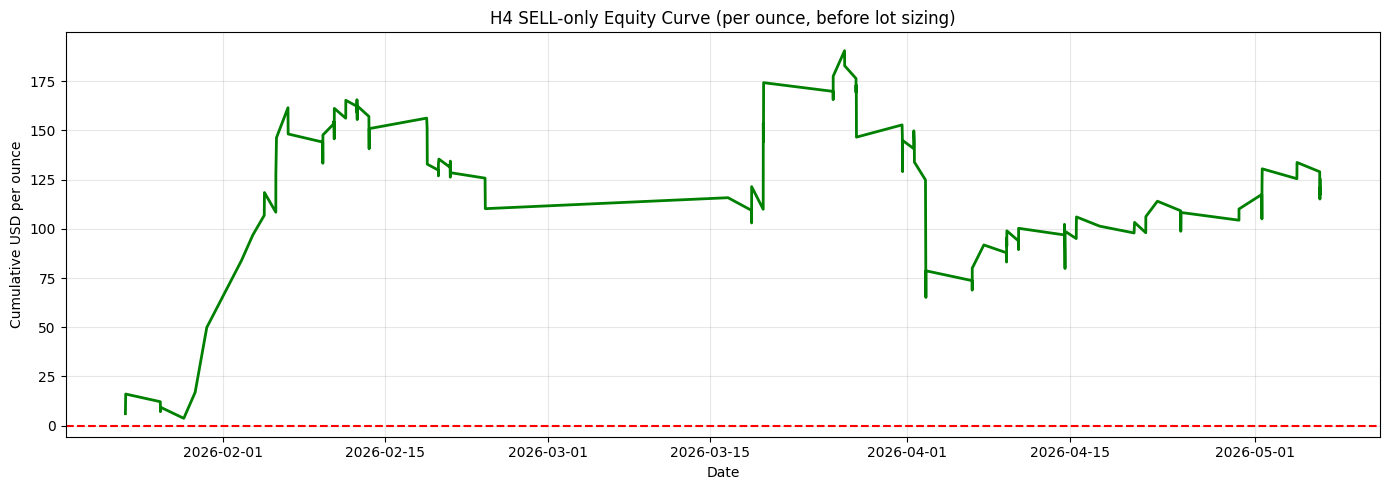


Max drawdown analysis:
Max drawdown: $-125.36
Final equity: $124.85


In [12]:
# === H4 SELL-only ===
sells_only = trades_h4_df[trades_h4_df['direction'] == 'SELL']

print(f"=== H4 SELL-ONLY ===\n")
print(f"Total trades: {len(sells_only)}")

wins = sells_only[sells_only['net_pl_usd'] > 0]
losses = sells_only[sells_only['net_pl_usd'] <= 0]

win_rate = len(wins) / len(sells_only) * 100
gross_profit = wins['net_pl_usd'].sum()
gross_loss = abs(losses['net_pl_usd'].sum())
profit_factor = gross_profit / gross_loss if gross_loss > 0 else float('inf')
total_pl = sells_only['net_pl_usd'].sum()

print(f"Win rate:      {win_rate:.1f}%")
print(f"Avg win:       ${wins['net_pl_usd'].mean():.2f}")
print(f"Avg loss:      ${losses['net_pl_usd'].mean():.2f}")
print(f"Profit factor: {profit_factor:.2f}")
print(f"Total P/L:     ${total_pl:.2f}")
print(f"Per trade:     ${sells_only['net_pl_usd'].mean():.2f}")

# Trades per day
days = sells_only['entry_time'].dt.date.nunique()
print(f"\nActive trading days: {days}")
print(f"Trades per active day: {len(sells_only)/days:.1f}")

# Equity curve
sells_sorted = sells_only.sort_values('entry_time').reset_index(drop=True)
sells_sorted['cumulative_pl'] = sells_sorted['net_pl_usd'].cumsum()

# Plot it
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sells_sorted['entry_time'], sells_sorted['cumulative_pl'], 
        color='green', linewidth=2)
ax.axhline(y=0, color='red', linestyle='--')
ax.set_title('H4 SELL-only Equity Curve (per ounce, before lot sizing)')
ax.set_ylabel('Cumulative USD per ounce')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/04_h4_sell_equity.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nMax drawdown analysis:")
running_max = sells_sorted['cumulative_pl'].cummax()
drawdown = sells_sorted['cumulative_pl'] - running_max
print(f"Max drawdown: ${drawdown.min():.2f}")
print(f"Final equity: ${sells_sorted['cumulative_pl'].iloc[-1]:.2f}")

Midpoint: 2026-03-16 00:00:00
In-sample period:    2026-01-22 00:00:00 → 2026-03-16 00:00:00
Out-of-sample period: 2026-03-16 00:00:00 → 2026-05-07 00:00:00

IN-SAMPLE (first half):
  Trades:        61
  Win rate:      41.0%
  PF:            1.65
  Total P/L:     $110.22
  Per trade:     $1.81

OUT-OF-SAMPLE (second half):
  Trades:        91
  Win rate:      36.3%
  PF:            1.04
  Total P/L:     $14.63
  Per trade:     $0.16


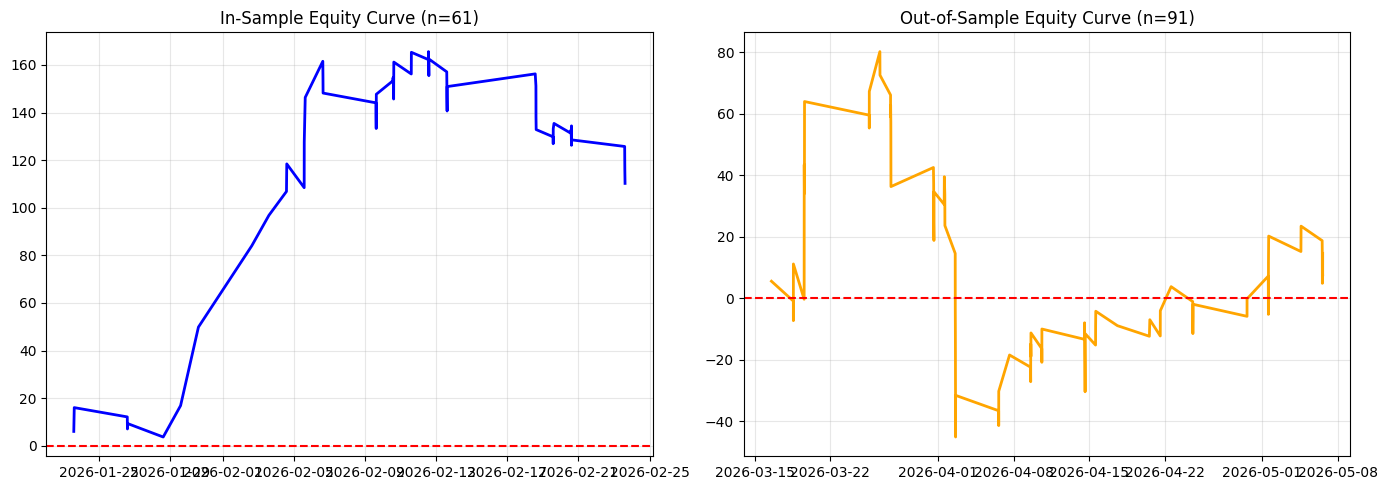

In [13]:
# === WALK-FORWARD VALIDATION ===
# Split data 50/50 by date, test if H4-SELL holds on out-of-sample

# Get the midpoint date
all_dates = sorted(df.index.normalize().unique())
midpoint_date = all_dates[len(all_dates) // 2]
print(f"Midpoint: {midpoint_date}")
print(f"In-sample period:    {all_dates[0]} → {midpoint_date}")
print(f"Out-of-sample period: {midpoint_date} → {all_dates[-1]}")

# Split trades_h4_df by entry_time
in_sample = trades_h4_df[
    (trades_h4_df['direction'] == 'SELL') & 
    (trades_h4_df['entry_time'] < midpoint_date)
]
out_sample = trades_h4_df[
    (trades_h4_df['direction'] == 'SELL') & 
    (trades_h4_df['entry_time'] >= midpoint_date)
]

def summarize(name, t):
    if len(t) == 0:
        print(f"\n{name}: NO TRADES")
        return
    wins = t[t['net_pl_usd'] > 0]
    losses = t[t['net_pl_usd'] <= 0]
    pf = wins['net_pl_usd'].sum() / abs(losses['net_pl_usd'].sum()) if len(losses) > 0 and losses['net_pl_usd'].sum() != 0 else float('inf')
    print(f"\n{name}:")
    print(f"  Trades:        {len(t)}")
    print(f"  Win rate:      {(t['net_pl_usd']>0).mean()*100:.1f}%")
    print(f"  PF:            {pf:.2f}")
    print(f"  Total P/L:     ${t['net_pl_usd'].sum():.2f}")
    print(f"  Per trade:     ${t['net_pl_usd'].mean():.2f}")

summarize("IN-SAMPLE (first half)", in_sample)
summarize("OUT-OF-SAMPLE (second half)", out_sample)

# Equity curves of both halves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(in_sample) > 0:
    is_sorted = in_sample.sort_values('entry_time').reset_index(drop=True)
    is_sorted['cum'] = is_sorted['net_pl_usd'].cumsum()
    axes[0].plot(is_sorted['entry_time'], is_sorted['cum'], color='blue', linewidth=2)
    axes[0].axhline(y=0, color='red', linestyle='--')
    axes[0].set_title(f'In-Sample Equity Curve (n={len(in_sample)})')
    axes[0].grid(True, alpha=0.3)

if len(out_sample) > 0:
    os_sorted = out_sample.sort_values('entry_time').reset_index(drop=True)
    os_sorted['cum'] = os_sorted['net_pl_usd'].cumsum()
    axes[1].plot(os_sorted['entry_time'], os_sorted['cum'], color='orange', linewidth=2)
    axes[1].axhline(y=0, color='red', linestyle='--')
    axes[1].set_title(f'Out-of-Sample Equity Curve (n={len(out_sample)})')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/05_walkforward.png', dpi=100, bbox_inches='tight')
plt.show()

In [14]:
# === HYPOTHESIS 5b: FILTERED ORB ===
# Filters derived from H5 diagnostics:
# 1. Only trade ranges > $8
# 2. No entries after 15:00 UTC
# 3. Exit at 90 min if no SL/TP hit (vs session_end)

MIN_RANGE_SIZE     = 8.0       # NEW: minimum range to trade
MAX_ENTRY_HOUR     = 14        # NEW: no entries at 15:00 UTC
MAX_HOLD_BARS      = 18        # NEW: 18 M5 bars = 90 minutes

MAX_SPREAD     = 0.40
ENTRY_COST_USD = 0.33

trades_orb_filtered = []

unique_dates = sorted(m5['date'].unique())
print(f"Processing {len(unique_dates)} trading days with filters...")

for date in unique_dates:
    day_data = m5[m5['date'] == date]
    
    # Range window: 13:00-13:25 UTC (first 30 min of NY)
    range_window = day_data[
        (day_data.index.hour == 13) & 
        (day_data.index.minute < 30)
    ]
    
    if len(range_window) < 4:
        continue
    
    range_high = range_window['High'].max()
    range_low  = range_window['Low'].min()
    range_size = range_high - range_low
    
    # FILTER 1: Range size minimum
    if range_size < MIN_RANGE_SIZE:
        continue
    
    # Trading window: 13:30 to 15:00 UTC (no entries after that)
    trading_window = day_data[
        ((day_data.index.hour == 13) & (day_data.index.minute >= 30)) |
        ((day_data.index.hour > 13) & (day_data.index.hour <= MAX_ENTRY_HOUR))
    ]
    
    if len(trading_window) == 0:
        continue
    
    # Find first breakout
    direction = None
    entry_price = None
    entry_time = None
    entry_idx = None
    
    for idx, bar in trading_window.iterrows():
        if bar['spread_usd'] > MAX_SPREAD:
            continue
        if bar['Close'] > range_high and direction is None:
            direction = 'BUY'
            entry_price = bar['Close']
            entry_time = idx
            entry_idx = day_data.index.get_loc(idx)
            break
        elif bar['Close'] < range_low and direction is None:
            direction = 'SELL'
            entry_price = bar['Close']
            entry_time = idx
            entry_idx = day_data.index.get_loc(idx)
            break
    
    if direction is None:
        continue
    
    if direction == 'BUY':
        sl = range_low
        tp = entry_price + range_size
    else:
        sl = range_high
        tp = entry_price - range_size
    
    # Walk forward with hard 90-minute (18 bar) limit
    remaining = day_data.iloc[entry_idx + 1 : entry_idx + 1 + MAX_HOLD_BARS]
    # Also clamp to before 16:00 UTC
    remaining = remaining[remaining.index.hour < 16]
    
    exit_price, exit_reason, exit_time = None, None, None
    
    for idx, bar in remaining.iterrows():
        if direction == 'BUY':
            if bar['Low'] <= sl:
                exit_price, exit_reason, exit_time = sl, 'SL', idx
                break
            if bar['High'] >= tp:
                exit_price, exit_reason, exit_time = tp, 'TP', idx
                break
        else:
            if bar['High'] >= sl:
                exit_price, exit_reason, exit_time = sl, 'SL', idx
                break
            if bar['Low'] <= tp:
                exit_price, exit_reason, exit_time = tp, 'TP', idx
                break
    
    # If no SL/TP hit, exit at end of allowed window
    if exit_price is None:
        if len(remaining) > 0:
            last_bar = remaining.iloc[-1]
            exit_price = last_bar['Close']
            exit_reason = 'TIMEOUT_90MIN'
            exit_time = remaining.index[-1]
        else:
            continue
    
    if direction == 'BUY':
        gross_pl = exit_price - entry_price
    else:
        gross_pl = entry_price - exit_price
    
    net_pl = gross_pl - (ENTRY_COST_USD * 2)
    
    trades_orb_filtered.append({
        'date': date,
        'entry_time': entry_time,
        'year': entry_time.year,
        'direction': direction,
        'range_high': range_high,
        'range_low': range_low,
        'range_size': range_size,
        'entry': entry_price,
        'sl': sl,
        'tp': tp,
        'exit_time': exit_time,
        'exit': exit_price,
        'exit_reason': exit_reason,
        'gross_pl_usd': gross_pl,
        'net_pl_usd': net_pl
    })

trades_orb_f_df = pd.DataFrame(trades_orb_filtered)

print(f"\n=== FILTERED ORB RESULTS (5 YEARS TRAINING DATA) ===\n")
print(f"Total trades: {len(trades_orb_f_df):,}")
print(f"(Was 1,241 unfiltered — dropped {1241 - len(trades_orb_f_df)} trades)")

if len(trades_orb_f_df) > 0:
    def summarize(name, t):
        if len(t) == 0:
            print(f"\n{name}: NO TRADES")
            return
        wins = t[t['net_pl_usd'] > 0]
        losses = t[t['net_pl_usd'] <= 0]
        pf = wins['net_pl_usd'].sum() / abs(losses['net_pl_usd'].sum()) if len(losses) > 0 and losses['net_pl_usd'].sum() != 0 else float('inf')
        print(f"\n{name}:")
        print(f"  Trades:     {len(t):,}")
        print(f"  Win rate:   {(t['net_pl_usd']>0).mean()*100:.1f}%")
        print(f"  PF:         {pf:.2f}")
        print(f"  Total P/L:  ${t['net_pl_usd'].sum():.2f}")
        print(f"  Per trade:  ${t['net_pl_usd'].mean():.2f}")
        print(f"  Avg win:    ${wins['net_pl_usd'].mean() if len(wins) > 0 else 0:.2f}")
        print(f"  Avg loss:   ${losses['net_pl_usd'].mean() if len(losses) > 0 else 0:.2f}")
    
    print("\n=== OVERALL ===")
    summarize("All", trades_orb_f_df)
    summarize("BUY only", trades_orb_f_df[trades_orb_f_df['direction'] == 'BUY'])
    summarize("SELL only", trades_orb_f_df[trades_orb_f_df['direction'] == 'SELL'])
    
    print("\n\n=== BY YEAR ===")
    print(f"{'Year':<8}{'Trades':<10}{'Win%':<8}{'PF':<8}{'Total':<10}{'PerTrade':<10}")
    print("-" * 55)
    for year in sorted(trades_orb_f_df['year'].unique()):
        subset = trades_orb_f_df[trades_orb_f_df['year'] == year]
        if len(subset) == 0:
            continue
        wins = subset[subset['net_pl_usd'] > 0]
        losses = subset[subset['net_pl_usd'] <= 0]
        pf = wins['net_pl_usd'].sum() / abs(losses['net_pl_usd'].sum()) if len(losses) > 0 and losses['net_pl_usd'].sum() != 0 else float('inf')
        wr = (subset['net_pl_usd'] > 0).mean() * 100
        total = subset['net_pl_usd'].sum()
        per = subset['net_pl_usd'].mean()
        print(f"{year:<8}{len(subset):<10}{wr:<8.1f}{pf:<8.2f}{total:<10.2f}{per:<10.2f}")
    
    print(f"\n\nExit reasons:")
    print(trades_orb_f_df['exit_reason'].value_counts())
    
    # Equity curve
    sorted_trades = trades_orb_f_df.sort_values('entry_time').reset_index(drop=True)
    sorted_trades['cumulative'] = sorted_trades['net_pl_usd'].cumsum()
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(sorted_trades['entry_time'], sorted_trades['cumulative'], color='blue', linewidth=1.5)
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_title('Filtered ORB Equity Curve (5 years training)')
    ax.set_ylabel('Cumulative USD per ounce')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('research/phase0/results/filtered_orb_equity.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Drawdown
    running_max = sorted_trades['cumulative'].cummax()
    drawdown = sorted_trades['cumulative'] - running_max
    print(f"\n=== Risk metrics ===")
    print(f"Max drawdown: ${drawdown.min():.2f}")
    print(f"Final equity: ${sorted_trades['cumulative'].iloc[-1]:.2f}")
    print(f"DD/Profit ratio: {abs(drawdown.min()) / max(sorted_trades['cumulative'].iloc[-1], 1):.2f}")

NameError: name 'm5' is not defined